<a href="https://colab.research.google.com/github/maryamnoureen/iomt-reliability-security/blob/main/IoMT_Reliability_Security.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
================================================================================
IoMT Device Reliability and Security Exposure: Menu-Driven Application
Author: Neo (IoT Security Analyst) / IoMT Assessment Group
================================================================================
Implementation Constraints Satisfied:
1. Developed purely in Python (Standard Library only; zero 3rd-party dependencies).
2. Fully interactive, robust, menu-driven CLI application.
3. No dedicated/ready-made black-box libraries (NO cryptography, NO PIL, NO numpy,
   NO scipy, NO networkx).
4. All linear algebra, matrix operations, cascade propagation, queue loss models,
   and numerical sensitivity derivatives implemented from scratch by the group.
5. Meaningful mathematical model with explicit justifications for every metric.
6. Strict constraint: Edge reliability cannot be assigned directly; it is derived
   dynamically from connected devices and their relationships.
================================================================================
"""

import math
import random
import copy
import sys


# ==============================================================================
# SECTION 1: FROM-SCRATCH MATHEMATICAL & LINEAR ALGEBRA ENGINE
# (No numpy, no scipy, no external libraries)
# ==============================================================================

def matrix_zeros(rows: int, cols: int) -> list:
    """Creates a rows x cols matrix filled with zeros using pure Python lists."""
    return [[0.0 for _ in range(cols)] for _ in range(rows)]


def matrix_identity(n: int) -> list:
    """Creates an n x n identity matrix from scratch."""
    I = matrix_zeros(n, n)
    for i in range(n):
        I[i][i] = 1.0
    return I


def matrix_multiply(A: list, B: list) -> list:
    """
    Multiplies matrix A (m x k) by matrix B (k x n) from scratch.
    Time Complexity: O(m * k * n).
    """
    m = len(A)
    k = len(A[0]) if m > 0 else 0
    n = len(B[0]) if len(B) > 0 else 0
    result = matrix_zeros(m, n)
    for i in range(m):
        for p in range(k):
            if A[i][p] != 0.0:
                for j in range(n):
                    result[i][j] += A[i][p] * B[p][j]
    return result


def matrix_add(A: list, B: list) -> list:
    """Adds two matrices element-wise."""
    rows = len(A)
    cols = len(A[0])
    result = matrix_zeros(rows, cols)
    for i in range(rows):
        for j in range(cols):
            result[i][j] = A[i][j] + B[i][j]
    return result


def matrix_scale(A: list, scalar: float) -> list:
    """Multiplies a matrix by a scalar factor."""
    rows = len(A)
    cols = len(A[0])
    result = matrix_zeros(rows, cols)
    for i in range(rows):
        for j in range(cols):
            result[i][j] = A[i][j] * scalar
    return result


def column_normalize_adjacency(A: list) -> list:
    """
    Normalizes columns of adjacency matrix A so that sum_u A[u][v] <= 1.0.
    This guarantees that the spectral radius rho(A_norm) <= 1,
    which mathematically guarantees convergence of the Neumann series:
    (I - alpha * A_norm)^(-1) - I = sum_{m=1}^inf alpha^m (A_norm)^m.
    """
    n = len(A)
    if n == 0:
        return []
    col_sums = [0.0 for _ in range(n)]
    for v in range(n):
        for u in range(n):
            col_sums[v] += A[u][v]

    A_norm = matrix_zeros(n, n)
    for u in range(n):
        for v in range(n):
            if col_sums[v] > 1.0:
                A_norm[u][v] = A[u][v] / col_sums[v]
            else:
                A_norm[u][v] = A[u][v]
    return A_norm


def compute_neumann_cascade_matrix(A_norm: list, alpha: float = 0.25, max_hops: int = 7) -> list:
    """
    Computes the Total Cascade Matrix Gamma using the Neumann Series:
    Gamma = sum_{m=1}^{max_hops} alpha^m * (A_norm)^m

    Mathematical justification:
    - m = 1 represents direct 1-hop dependencies (Device j directly impacts Device i).
    - m = 2 represents indirect 2-hop cascades (Device j impacts k, which impacts i).
    - m >= 3 represents higher-order ripple effects.
    - alpha^m provides geometric attenuation: multi-hop cascades diminish in impact.
    """
    n = len(A_norm)
    if n == 0:
        return []

    gamma = matrix_zeros(n, n)
    current_power = [row[:] for row in A_norm]  # (A_norm)^1
    alpha_power = alpha

    for hop in range(1, max_hops + 1):
        scaled_power = matrix_scale(current_power, alpha_power)
        gamma = matrix_add(gamma, scaled_power)
        current_power = matrix_multiply(current_power, A_norm)
        alpha_power *= alpha

    return gamma


# ==============================================================================
# SECTION 2: PROTOCOL CATALOG & THREAT PARAMETERS
# (Pure Python dictionary structures; no third-party network libraries)
# ==============================================================================

PROTOCOLS = {
    # Wired Protocols
    "1": {
        "key": "Ethernet_TLS",
        "name": "Ethernet (TLS 1.3)",
        "family": "Wired",
        "medium_exposure": 0.08,      # Low: requires physical galvanic line tap
        "encryption_strength": 0.98,  # TLS 1.3 / AES-256
        "cve_exploitability": 0.10,   # Standardized, robust implementation
        "packet_loss_rate": 0.001,    # 0.1% baseline error rate
        "bandwidth_capacity": 5000.0, # 5,000 packets/sec
    },
    "2": {
        "key": "RS485_Modbus",
        "name": "RS-485 Modbus (Cleartext)",
        "family": "Wired",
        "medium_exposure": 0.25,      # Wired bus tap vulnerability
        "encryption_strength": 0.05,  # Cleartext; no auth or encryption
        "cve_exploitability": 0.45,   # Easily spoofed on shared serial bus
        "packet_loss_rate": 0.005,    # 0.5% baseline
        "bandwidth_capacity": 250.0,  # 250 packets/sec
    },
    "3": {
        "key": "USB_Medical",
        "name": "USB-C Medical Serial",
        "family": "Wired",
        "medium_exposure": 0.12,      # Local port access
        "encryption_strength": 0.70,  # Proprietary checksum / session keys
        "cve_exploitability": 0.20,   # Low external surface
        "packet_loss_rate": 0.002,    # 0.2% baseline
        "bandwidth_capacity": 2000.0, # 2,000 packets/sec
    },
    # Wireless Protocols
    "4": {
        "key": "BLE_5_Secure",
        "name": "BLE 5.2 (AES-CCM Encrypted)",
        "family": "Wireless",
        "medium_exposure": 0.55,      # Open RF propagation (sniffing possible)
        "encryption_strength": 0.88,  # AES-128 CCM authenticated encryption
        "cve_exploitability": 0.30,   # Pairing & bonding attack surface
        "packet_loss_rate": 0.025,    # 2.5% RF interference packet loss
        "bandwidth_capacity": 800.0,  # 800 packets/sec
    },
    "5": {
        "key": "BLE_Legacy",
        "name": "BLE 4.0 (Cleartext Legacy)",
        "family": "Wireless",
        "medium_exposure": 0.85,      # High: broadcast over-the-air in plain
        "encryption_strength": 0.20,  # Weak PIN / PIN crackable
        "cve_exploitability": 0.75,   # Known BlueBorne / SweynTooth flaws
        "packet_loss_rate": 0.050,    # 5% packet loss
        "bandwidth_capacity": 400.0,  # 400 packets/sec
    },
    "6": {
        "key": "WiFi_WPA3",
        "name": "Wi-Fi 6 (WPA3-Enterprise)",
        "family": "Wireless",
        "medium_exposure": 0.60,      # RF propagation
        "encryption_strength": 0.95,  # 192-bit cryptographic suite
        "cve_exploitability": 0.25,   # Protected Management Frames (PMF)
        "packet_loss_rate": 0.015,    # 1.5% loss
        "bandwidth_capacity": 4000.0, # 4,000 packets/sec
    },
    "7": {
        "key": "WiFi_WPA2_PSK",
        "name": "Wi-Fi 802.11ac (WPA2-PSK)",
        "family": "Wireless",
        "medium_exposure": 0.72,      # Deauthentication / 4-way handshake sniffing
        "encryption_strength": 0.65,  # Pre-shared key susceptible to dictionary attack
        "cve_exploitability": 0.50,   # KRACK vulnerability surface
        "packet_loss_rate": 0.025,    # 2.5% loss
        "bandwidth_capacity": 2500.0, # 2,500 packets/sec
    },
    "8": {
        "key": "Zigbee_Pro",
        "name": "Zigbee Health Care (802.15.4)",
        "family": "Wireless",
        "medium_exposure": 0.65,      # RF mesh sniffing
        "encryption_strength": 0.78,  # AES-128 network key
        "cve_exploitability": 0.38,   # Key exchange during joining
        "packet_loss_rate": 0.035,    # 3.5% loss
        "bandwidth_capacity": 300.0,  # 300 packets/sec
    },
    "9": {
        "key": "Cellular_5G",
        "name": "5G Private Network (URLLC)",
        "family": "Wireless",
        "medium_exposure": 0.35,      # Licensed cellular spectrum
        "encryption_strength": 0.96,  # 5G AKA / 256-bit subscriber crypto
        "cve_exploitability": 0.18,   # Network slicing isolation
        "packet_loss_rate": 0.005,    # Ultra-reliable 0.5% loss
        "bandwidth_capacity": 6000.0, # 6,000 packets/sec
    },
}


# ==============================================================================
# SECTION 3: SYSTEM DATA STRUCTURES & VALIDATIONS
# (Constraint: Every device must contain at least 2 sensors)
# ==============================================================================

class Sensor:
    def __init__(self, sensor_id: str, name: str, reliability: float = 1.0, measurement_type: str = "vital_signs"):
        self.sensor_id = sensor_id
        self.name = name
        self.reliability = max(0.0, min(1.0, float(reliability)))
        self.measurement_type = measurement_type

    def to_dict(self):
        return {
            "id": self.sensor_id,
            "name": self.name,
            "reliability": self.reliability,
            "type": self.measurement_type
        }


class Device:
    def __init__(self, device_id: str, name: str, device_type: str, protocol_key: str,
                 frequency_hz: float, sensors: list, initial_reliability: float = 85.0,
                 clinical_weight: float = 5.0):
        # Enforce Constraint: At least 2 sensors per device
        if len(sensors) < 2:
            raise ValueError(f"VALIDATION ERROR: Device '{device_id}' must have at least 2 sensors! (Received {len(sensors)})")
        if frequency_hz <= 0:
            raise ValueError(f"VALIDATION ERROR: Frequency must be strictly positive! (Received {frequency_hz} Hz)")

        self.device_id = device_id
        self.name = name
        self.device_type = device_type
        self.protocol_key = protocol_key
        self.frequency_hz = float(frequency_hz)
        self.sensors = sensors  # List of Sensor objects
        self.initial_reliability = max(0.0, min(100.0, float(initial_reliability)))
        self.clinical_weight = max(1.0, min(10.0, float(clinical_weight)))

        # Evaluated Metrics
        self.sensor_subsystem_reliability = 0.0
        self.channel_reliability = 0.0
        self.cascade_retention = 0.0
        self.security_exposure = 0.0
        self.updated_reliability = 0.0
        self.criticality_score = 0.0
        self.marginal_edge_sensitivity = 0.0

    @property
    def sensor_count(self) -> int:
        return len(self.sensors)

    @property
    def total_packet_rate(self) -> float:
        """Every sensor sends its readings separately at frequency_hz."""
        return self.sensor_count * self.frequency_hz

    def get_protocol_profile(self) -> dict:
        for p in PROTOCOLS.values():
            if p["key"] == self.protocol_key:
                return p
        # Default fallback
        return PROTOCOLS["1"]


class IoMTNetwork:
    """
    Manages connected devices, dependencies, and computes mathematical scores.
    """
    def __init__(self, gateway_capacity: float = 5000.0):
        self.devices = {}         # device_id -> Device
        self.dependencies = {}    # source_id -> { target_id: weight }
        self.gateway_capacity = float(gateway_capacity)
        self.attenuation_alpha = 0.25
        self.sec_coupling = 0.20  # 20% degradation penalty at 100% security exposure

    def add_device(self, device: Device):
        self.devices[device.device_id] = device
        if device.device_id not in self.dependencies:
            self.dependencies[device.device_id] = {}

    def remove_device(self, device_id: str):
        if device_id in self.devices:
            del self.devices[device_id]
        if device_id in self.dependencies:
            del self.dependencies[device_id]
        for src in self.dependencies:
            if device_id in self.dependencies[src]:
                del self.dependencies[src][device_id]

    def set_dependency(self, source_id: str, target_id: str, weight: float):
        if source_id not in self.devices or target_id not in self.devices:
            raise KeyError("Both source and target devices must exist in the network!")
        if source_id == target_id:
            raise ValueError("A device cannot depend on itself!")
        w = max(0.0, min(1.0, float(weight)))
        if source_id not in self.dependencies:
            self.dependencies[source_id] = {}
        self.dependencies[source_id][target_id] = w

    def remove_dependency(self, source_id: str, target_id: str):
        if source_id in self.dependencies and target_id in self.dependencies[source_id]:
            del self.dependencies[source_id][target_id]

    def assign_random_reliabilities(self, min_rel: float = 60.0, max_rel: float = 98.0, seed: int = None):
        """Randomly initializes device baseline reliability within defined range."""
        if seed is not None:
            random.seed(seed)
        for dev in self.devices.values():
            dev.initial_reliability = round(random.uniform(min_rel, max_rel), 2)
            for s in dev.sensors:
                s.reliability = round(random.uniform(0.92, 1.0), 3)

    # -------------------------------------------------------------------------
    # MATHEMATICAL FORMULATION EVALUATION
    # -------------------------------------------------------------------------

    def evaluate(self) -> dict:
        """
        Calculates Device Reliability, Security Exposure, and DERIVES Edge Reliability.
        Constraint Enforced: Edge reliability cannot be set; it is strictly derived.
        """
        dev_ids = list(self.devices.keys())
        n = len(dev_ids)
        if n == 0:
            return {
                "total_devices": 0,
                "total_sensors": 0,
                "aggregate_packet_rate": 0.0,
                "gateway_capacity": self.gateway_capacity,
                "load_factor": 0.0,
                "load_penalty": 1.0,
                "aggregate_device_health": 0.0,
                "edge_security_exposure": 0.0,
                "edge_security_resilience": 1.0,
                "derived_edge_reliability": 0.0,
            }

        # Step 1: Build adjacency matrix A from scratch
        idx_map = {dev_ids[i]: i for i in range(n)}
        A = matrix_zeros(n, n)
        for src_id, targets in self.dependencies.items():
            if src_id in idx_map:
                u = idx_map[src_id]
                for tgt_id, w in targets.items():
                    if tgt_id in idx_map:
                        v = idx_map[tgt_id]
                        A[u][v] = w

        # Step 2: Column Normalize & compute Neumann Series Cascade Matrix
        A_norm = column_normalize_adjacency(A)
        gamma = compute_neumann_cascade_matrix(A_norm, alpha=self.attenuation_alpha, max_hops=7)

        gamma_map = {dev_ids[i]: {} for i in range(n)}
        for i in range(n):
            for j in range(n):
                gamma_map[dev_ids[i]][dev_ids[j]] = gamma[i][j]

        # Step 3: Compute Device Sensor, Channel, Cascade & Security Scores
        for dev_id, dev in self.devices.items():
            proto = dev.get_protocol_profile()
            lambda_i = dev.total_packet_rate

            # 3.1 Sensor Subsystem: completeness * survival redundancy
            s_count = dev.sensor_count
            avg_sens = sum(s.reliability for s in dev.sensors) / s_count
            prod_unrel = 1.0
            for s in dev.sensors:
                prod_unrel *= max(0.0, 1.0 - s.reliability)
            dev.sensor_subsystem_reliability = avg_sens * (1.0 - prod_unrel)

            # 3.2 Channel Transmission Reliability: buffer stress decay
            cap = proto["bandwidth_capacity"]
            ratio = lambda_i / cap
            dev.channel_reliability = (1.0 - proto["packet_loss_rate"]) * math.exp(-0.8 * (ratio ** 2))

            # 3.3 Cascade Operational Retention: upstream unreliability propagation
            prod_ret = 1.0
            for j_id, j_dev in self.devices.items():
                if j_id != dev_id:
                    gamma_ji = gamma_map.get(j_id, {}).get(dev_id, 0.0)
                    if gamma_ji > 0.0001:
                        unrel_j = 1.0 - (j_dev.initial_reliability / 100.0)
                        prod_ret *= (1.0 - min(0.90, gamma_ji * unrel_j))
            dev.cascade_retention = max(0.05, prod_ret)

            # 3.4 Intrinsic Security Exposure
            freq_factor = 1.0 - math.exp(-0.015 * lambda_i)
            se_int = 100.0 * (
                0.35 * proto["medium_exposure"] +
                0.35 * (1.0 - proto["encryption_strength"]) +
                0.15 * proto["cve_exploitability"] +
                0.15 * freq_factor
            )
            se_int = max(0.0, min(100.0, se_int))

            # 3.5 Lateral Network Contagion from upstream dependencies
            prod_lat = 1.0
            for j_id, j_dev in self.devices.items():
                if j_id != dev_id:
                    gamma_ji = gamma_map.get(j_id, {}).get(dev_id, 0.0)
                    if gamma_ji > 0.001:
                        j_proto = j_dev.get_protocol_profile()
                        j_freq = 1.0 - math.exp(-0.015 * j_dev.total_packet_rate)
                        j_se_int = 100.0 * (
                            0.35 * j_proto["medium_exposure"] +
                            0.35 * (1.0 - j_proto["encryption_strength"]) +
                            0.15 * j_proto["cve_exploitability"] +
                            0.15 * j_freq
                        )
                        prod_lat *= (1.0 - min(0.95, gamma_ji * (j_se_int / 100.0)))
            se_lat = 100.0 * (1.0 - prod_lat)
            dev.security_exposure = round(max(0.0, min(100.0, se_int + 0.40 * se_lat * (1.0 - se_int / 100.0))), 2)

            # 3.6 Updated Operational Reliability Score (0-100 scale)
            sec_penalty = 1.0 - (self.sec_coupling * (dev.security_exposure / 100.0))
            raw_r = (
                (dev.initial_reliability / 100.0) *
                dev.sensor_subsystem_reliability *
                dev.channel_reliability *
                dev.cascade_retention *
                sec_penalty
            ) * 100.0
            dev.updated_reliability = round(max(0.0, min(100.0, raw_r)), 2)

        # Step 4: DERIVE Edge Gateway Reliability (MANDATORY CONSTRAINT)
        total_sensors = sum(d.sensor_count for d in self.devices.values())
        agg_rate = sum(d.total_packet_rate for d in self.devices.values())
        load_factor = agg_rate / self.gateway_capacity

        # Factor A: Ingress Traffic Congestion Penalty
        if load_factor <= 0.70:
            load_penalty = 1.0
        elif load_factor <= 1.0:
            load_penalty = 1.0 - 0.40 * (((load_factor - 0.70) / 0.30) ** 2)
        else:
            load_penalty = 0.60 * math.exp(-2.5 * (load_factor - 1.0))
        load_penalty = max(0.05, min(1.0, load_penalty))

        # Factor B: Clinically-Weighted Aggregate Health
        out_centralities = {
            d_id: sum(gamma_map[d_id][other] for other in dev_ids if other != d_id)
            for d_id in dev_ids
        }
        weights = {
            d_id: self.devices[d_id].clinical_weight * (1.0 + 0.5 * out_centralities[d_id])
            for d_id in dev_ids
        }
        sum_w = sum(weights.values())
        agg_health = sum((weights[d_id] / sum_w) * self.devices[d_id].updated_reliability for d_id in dev_ids)

        # Factor C: Gateway Ingress Security Resilience
        prod_edge_sec = 1.0
        for dev in self.devices.values():
            proto = dev.get_protocol_profile()
            traf_share = dev.total_packet_rate / max(1.0, agg_rate)
            med_mult = 1.2 if proto["family"] == "Wireless" else 0.8
            ingress_weight = min(0.35, traf_share * med_mult)
            prod_edge_sec *= (1.0 - ingress_weight * (dev.security_exposure / 100.0))
        edge_sec_exp = 100.0 * (1.0 - prod_edge_sec)
        edge_resilience = 1.0 - 0.25 * (edge_sec_exp / 100.0)

        # STRICT DERIVATION: R_edge = agg_health * load_penalty * edge_resilience
        derived_edge_rel = round(max(0.0, min(100.0, agg_health * load_penalty * edge_resilience)), 2)

        # Step 5: Criticality & Marginal Sensitivity Derivatives
        max_blast = max(out_centralities.values()) if out_centralities and max(out_centralities.values()) > 0 else 1.0
        for d_id, dev in self.devices.items():
            w_norm = weights[d_id] / sum_w
            sens = w_norm * load_penalty * edge_resilience
            dev.marginal_edge_sensitivity = round(sens, 4)

            clin_s = dev.clinical_weight / 10.0
            blast_s = out_centralities[d_id] / max_blast
            traf_s = dev.total_packet_rate / max(1.0, agg_rate)
            crit = 100.0 * (0.35 * clin_s + 0.30 * blast_s + 0.20 * traf_s + 0.15 * min(1.0, sens * 5.0))
            dev.criticality_score = round(max(0.0, min(100.0, crit)), 1)

        return {
            "total_devices": n,
            "total_sensors": total_sensors,
            "aggregate_packet_rate": round(agg_rate, 2),
            "gateway_capacity": self.gateway_capacity,
            "load_factor": round(load_factor, 3),
            "load_penalty": round(load_penalty, 3),
            "aggregate_device_health": round(agg_health, 2),
            "edge_security_exposure": round(edge_sec_exp, 2),
            "edge_security_resilience": round(edge_resilience, 3),
            "derived_edge_reliability": derived_edge_rel,
            "gamma_map": gamma_map
        }


# ==============================================================================
# SECTION 4: PRESET HOSPITAL ICU NETWORK INITIALIZATION
# ==============================================================================

def create_default_hospital_network() -> IoMTNetwork:
    """Creates benchmark ICU network complying with all constraints."""
    net = IoMTNetwork(gateway_capacity=5000.0)

    # D1: Ventilator (3 sensors >= 2, Wired TLS, 10 Hz)
    net.add_device(Device(
        device_id="D1", name="ICU Mechanical Ventilator", device_type="Life Support",
        protocol_key="Ethernet_TLS", frequency_hz=10.0, initial_reliability=95.0, clinical_weight=10.0,
        sensors=[Sensor("D1_S1", "Airway Pressure Transducer", 0.99),
                 Sensor("D1_S2", "Inspiratory Flow Sensor", 0.98),
                 Sensor("D1_S3", "FiO2 Oxygen Sensor", 0.97)]
    ))

    # D2: Infusion Pump (2 sensors >= 2, BLE 5.2, 2 Hz)
    net.add_device(Device(
        device_id="D2", name="Smart Infusion Pump", device_type="Drug Delivery",
        protocol_key="BLE_5_Secure", frequency_hz=2.0, initial_reliability=92.0, clinical_weight=9.0,
        sensors=[Sensor("D2_S1", "Infusion Drop Sensor", 0.98),
                 Sensor("D2_S2", "Occlusion Pressure Sensor", 0.97)]
    ))

    # D3: Patient Monitor (4 sensors >= 2, Wi-Fi WPA3, 25 Hz)
    net.add_device(Device(
        device_id="D3", name="Bedside Patient Monitor", device_type="Multi-parameter Monitor",
        protocol_key="WiFi_WPA3", frequency_hz=25.0, initial_reliability=90.0, clinical_weight=8.5,
        sensors=[Sensor("D3_S1", "12-Lead ECG Sensor", 0.96),
                 Sensor("D3_S2", "SpO2 Pulse Oximeter", 0.97),
                 Sensor("D3_S3", "NIBP Blood Pressure Cuff", 0.95),
                 Sensor("D3_S4", "Core Temperature Probe", 0.98)]
    ))

    # D4: Dialysis Machine (2 sensors >= 2, RS-485 Modbus, 1 Hz)
    net.add_device(Device(
        device_id="D4", name="Hemodialysis Machine", device_type="Renal Replacement",
        protocol_key="RS485_Modbus", frequency_hz=1.0, initial_reliability=88.0, clinical_weight=8.0,
        sensors=[Sensor("D4_S1", "Venous Pressure Transducer", 0.96),
                 Sensor("D4_S2", "Ultrasonic Blood Flow", 0.95)]
    ))

    # D5: Wearable Continuous Patch (3 sensors >= 2, BLE Legacy, 5 Hz)
    net.add_device(Device(
        device_id="D5", name="Patient Continuous Patch", device_type="Ambulatory Wearable",
        protocol_key="BLE_Legacy", frequency_hz=5.0, initial_reliability=80.0, clinical_weight=4.0,
        sensors=[Sensor("D5_S1", "Optical PPG Sensor", 0.92),
                 Sensor("D5_S2", "Skin Surface Thermistor", 0.93),
                 Sensor("D5_S3", "Accelerometer (Fall Detect)", 0.91)]
    ))

    # Dependencies: D3 -> D2 (0.70), D1 -> D3 (0.50), D4 -> D2 (0.40), D5 -> D3 (0.35)
    net.set_dependency("D3", "D2", 0.70)
    net.set_dependency("D1", "D3", 0.50)
    net.set_dependency("D4", "D2", 0.40)
    net.set_dependency("D5", "D3", 0.35)

    return net


# ==============================================================================
# SECTION 5: CLI INTERFACE & FORMATTING UTILITIES
# ==============================================================================

def print_header(title: str):
    print("\n" + "=" * 80)
    print(f" {title}".center(80))
    print("=" * 80)


def print_table(headers: list, rows: list, widths: list):
    line = "+" + "+".join("-" * (w + 2) for w in widths) + "+"
    header_str = "|" + "|".join(f" {str(h):<{widths[i]}} " for i, h in enumerate(headers)) + "|"
    print(line)
    print(header_str)
    print(line)
    for row in rows:
        row_str = "|" + "|".join(f" {str(val):<{widths[i]}} " for i, val in enumerate(row)) + "|"
        print(row_str)
    print(line)


def get_float_input(prompt: str, min_val: float = None, max_val: float = None) -> float:
    while True:
        try:
            val = float(input(prompt).strip())
            if min_val is not None and val < min_val:
                print(f"  [!] Value must be >= {min_val}. Try again.")
                continue
            if max_val is not None and val > max_val:
                print(f"  [!] Value must be <= {max_val}. Try again.")
                continue
            return val
        except ValueError:
            print("  [!] Invalid number. Please enter a valid floating-point number.")


def get_int_input(prompt: str, min_val: int = None, max_val: int = None) -> int:
    while True:
        try:
            val = int(input(prompt).strip())
            if min_val is not None and val < min_val:
                print(f"  [!] Value must be >= {min_val}. Try again.")
                continue
            if max_val is not None and val > max_val:
                print(f"  [!] Value must be <= {max_val}. Try again.")
                continue
            return val
        except ValueError:
            print("  [!] Invalid integer. Please enter a valid whole number.")


# ==============================================================================
# SECTION 6: INTERACTIVE MENU-DRIVEN CONTROLLER
# ==============================================================================

class IoMTConsoleApp:
    def __init__(self):
        self.network = create_default_hospital_network()

    def run(self):
        while True:
            print_header("IoMT DEVICE RELIABILITY & SECURITY EXPOSURE CONSOLE (NEO)")
            print(" [1] View Current Network Topology, Devices & Dependencies")
            print(" [2] Set Up / Reset Network (Custom or Hospital ICU Preset)")
            print(" [3] Assign Initial Reliabilities (Manual or Random Range [R_min, R_max])")
            print(" [4] Add a New IoMT Device (Strict Constraint: Sensors >= 2)")
            print(" [5] Modify Device Properties (Frequency, Protocol, Sensors, Reliability)")
            print(" [6] Manage Inter-Device Dependency Relationships (Cascade Graph)")
            print(" [7] Calculate Scores (Device Reliability, Security Exposure & Derived Edge)")
            print(" [8] Criticality Ranking & Marginal Sensitivity Analysis (d(R_edge)/d(R_i))")
            print(" [9] Run Interactive 'What-If' Sensitivity Simulation (Before vs After)")
            print(" [10] Run Benchmark Clinical Scenarios (Attack, Traffic Storm, Hardening)")
            print(" [11] View Mathematical Reasoning, Formulations & 0-100 Scale Definitions")
            print(" [12] Exit Application")
            print("-" * 80)

            choice = input("Enter choice [1-12]: ").strip()

            if choice == "1":
                self.view_network()
            elif choice == "2":
                self.reset_or_custom_setup()
            elif choice == "3":
                self.assign_reliabilities_menu()
            elif choice == "4":
                self.add_device_menu()
            elif choice == "5":
                self.modify_device_menu()
            elif choice == "6":
                self.manage_dependencies_menu()
            elif choice == "7":
                self.display_calculated_scores()
            elif choice == "8":
                self.display_criticality_analysis()
            elif choice == "9":
                self.run_what_if_simulation()
            elif choice == "10":
                self.run_benchmark_scenarios()
            elif choice == "11":
                self.display_math_reasoning()
            elif choice == "12":
                print("\nExiting IoMT Assessment Console. Goodbye, Neo.")
                sys.exit(0)
            else:
                print("  [!] Invalid choice. Please enter a number between 1 and 12.")

    # --- Feature 1: View Current Network ---
    def view_network(self):
        print_header("CURRENT IoMT NETWORK TOPOLOGY & HARDWARE")
        if not self.network.devices:
            print("No devices currently registered in the network.")
            return

        headers = ["ID", "Device Name", "Category", "Protocol", "Family", "Sensors", "Freq(Hz)", "Rate(pkts/s)", "Base Rel"]
        widths = [4, 25, 18, 16, 8, 7, 8, 12, 8]
        rows = []
        for d in self.network.devices.values():
            proto = d.get_protocol_profile()
            rows.append([
                d.device_id, d.name[:25], d.device_type[:18], proto["name"][:16],
                proto["family"], d.sensor_count, f"{d.frequency_hz:.1f}",
                f"{d.total_packet_rate:.1f}", f"{d.initial_reliability:.1f}"
            ])
        print_table(headers, rows, widths)

        print("\nAttached Sensors Breakdown:")
        for d in self.network.devices.values():
            s_names = [f"{s.name} (r={s.reliability:.2f})" for s in d.sensors]
            print(f"  * {d.device_id} ({d.name}): {len(d.sensors)} sensors -> {', '.join(s_names)}")

        print("\nInter-Device Dependency Graph (Directed Influence Links):")
        dep_count = 0
        for src, tgts in self.network.dependencies.items():
            for tgt, w in tgts.items():
                dep_count += 1
                print(f"  * {src} ({self.network.devices[src].name}) ---> {tgt} ({self.network.devices[tgt].name}) | Weight: {w:.2f}")
        if dep_count == 0:
            print("  No dependencies configured. All devices operate independently.")

    # --- Feature 2: Reset or Setup ---
    def reset_or_custom_setup(self):
        print_header("SETUP / RESET NETWORK")
        print(" [1] Reset to Default Hospital ICU Benchmark (5 devices, 14 sensors, 4 dependencies)")
        print(" [2] Clear all devices and set up an entirely custom network")
        print(" [3] Back to Main Menu")
        c = input("Choose option [1-3]: ").strip()
        if c == "1":
            self.network = create_default_hospital_network()
            print("  [+] Successfully restored Default Hospital ICU Network!")
        elif c == "2":
            cap = get_float_input("Enter Edge Gateway Capacity (packets/sec) [e.g. 5000]: ", min_val=100.0)
            self.network = IoMTNetwork(gateway_capacity=cap)
            n_devs = get_int_input("How many medical devices do you want to configure initially? ", min_val=1)
            for i in range(1, n_devs + 1):
                print(f"\n--- Configuring Device {i} of {n_devs} ---")
                self.interactive_add_device(f"D{i}")
            print(f"\n  [+] Custom network with {len(self.network.devices)} devices created successfully!")
        elif c == "3":
            return

    # --- Feature 3: Assign Reliabilities ---
    def assign_reliabilities_menu(self):
        print_header("ASSIGN INITIAL DEVICE RELIABILITIES")
        print(" [1] Assign Random Reliabilities within Defined Range [R_min, R_max]")
        print(" [2] Assign Manually to Each Device")
        print(" [3] Back to Main Menu")
        c = input("Choose option [1-3]: ").strip()
        if c == "1":
            min_r = get_float_input("Enter minimum reliability bound (0 to 100) [e.g. 60.0]: ", 0.0, 100.0)
            max_r = get_float_input(f"Enter maximum reliability bound ({min_r} to 100) [e.g. 98.0]: ", min_r, 100.0)
            self.network.assign_random_reliabilities(min_rel=min_r, max_rel=max_r)
            print(f"  [+] Random initial reliabilities assigned uniformly in [{min_r}, {max_r}%] to all devices!")
        elif c == "2":
            for d in self.network.devices.values():
                val = get_float_input(f"Enter new initial reliability for {d.device_id} ({d.name}) [Current: {d.initial_reliability}%]: ", 0.0, 100.0)
                d.initial_reliability = val
            print("  [+] All device initial reliabilities updated!")

    # --- Feature 4: Add New Device ---
    def add_device_menu(self):
        print_header("ADD NEW IoMT DEVICE")
        next_num = len(self.network.devices) + 1
        default_id = f"D{next_num}"
        dev_id = input(f"Enter Device ID [Default: {default_id}]: ").strip() or default_id
        if dev_id in self.network.devices:
            print(f"  [!] Device ID '{dev_id}' already exists!")
            return
        self.interactive_add_device(dev_id)

    def interactive_add_device(self, dev_id: str):
        name = input(f"Enter Device Name [e.g., Smart Infusion Pump]: ").strip() or f"IoMT Device {dev_id}"
        dev_type = input(f"Enter Device Type [e.g., Life Support / Monitor]: ").strip() or "Telemetry Unit"

        print("\nSelect Communication Protocol:")
        for num, p in PROTOCOLS.items():
            print(f"  [{num}] {p['name']} ({p['family']}) - Bandwidth: {p['bandwidth_capacity']} pkts/s")
        p_choice = input("Enter protocol choice [1-9, Default 1]: ").strip() or "1"
        proto_key = PROTOCOLS.get(p_choice, PROTOCOLS["1"])["key"]

        freq = get_float_input("Enter sampling/sending frequency f_i (Hz = msgs/sec per sensor) [e.g. 5.0]: ", min_val=0.1)

        # STRICT CONSTRAINT ENFORCEMENT: >= 2 SENSORS
        print("\n[CONSTRAINT ENFORCEMENT] Every device must contain at least 2 sensors!")
        num_sensors = get_int_input("Enter number of attached sensors (MUST BE >= 2): ", min_val=2)

        sensors = []
        for s_idx in range(1, num_sensors + 1):
            s_name = input(f"  Enter name for Sensor {s_idx} [e.g. Lead {s_idx}]: ").strip() or f"Sensor {s_idx}"
            s_rel = get_float_input(f"  Enter health for Sensor {s_idx} (0.0 to 1.0) [Default 0.98]: ", 0.0, 1.0)
            sensors.append(Sensor(f"{dev_id}_S{s_idx}", s_name, s_rel))

        init_rel = get_float_input("Enter initial hardware reliability (0-100%) [Default 90.0]: ", 0.0, 100.0)
        clin_weight = get_float_input("Enter clinical patient safety weight (1 to 10) [Default 5.0]: ", 1.0, 10.0)

        device = Device(
            device_id=dev_id, name=name, device_type=dev_type, protocol_key=proto_key,
            frequency_hz=freq, sensors=sensors, initial_reliability=init_rel, clinical_weight=clin_weight
        )
        self.network.add_device(device)
        print(f"\n  [+] Successfully registered Device '{dev_id}' with {num_sensors} sensors!")

    # --- Feature 5: Modify Device ---
    def modify_device_menu(self):
        print_header("MODIFY DEVICE PROPERTIES")
        if not self.network.devices:
            print("No devices to modify.")
            return

        print("Available Devices:")
        for d_id, d in self.network.devices.items():
            print(f"  [{d_id}] {d.name} | Protocol: {d.protocol_key} | Freq: {d.frequency_hz} Hz | Sensors: {d.sensor_count}")

        target_id = input("\nEnter Device ID to modify: ").strip()
        if target_id not in self.network.devices:
            print(f"  [!] Device '{target_id}' not found.")
            return

        dev = self.network.devices[target_id]
        print(f"\nModifying Device '{dev.device_id}' ({dev.name}):")
        print(f" [1] Change Frequency (Current: {dev.frequency_hz} Hz)")
        print(f" [2] Change Protocol (Current: {dev.protocol_key})")
        print(f" [3] Change Initial Reliability (Current: {dev.initial_reliability}%)")
        print(f" [4] Add / Remove Sensors (Current count: {dev.sensor_count})")
        print(f" [5] Delete This Device")
        print(f" [6] Cancel")

        c = input("Choose action [1-6]: ").strip()
        if c == "1":
            dev.frequency_hz = get_float_input("Enter new frequency f_i (Hz): ", min_val=0.1)
            print("  [+] Frequency updated!")
        elif c == "2":
            print("\nSelect New Protocol:")
            for num, p in PROTOCOLS.items():
                print(f"  [{num}] {p['name']} ({p['family']})")
            p_c = input("Enter choice [1-9]: ").strip()
            if p_c in PROTOCOLS:
                dev.protocol_key = PROTOCOLS[p_c]["key"]
                print("  [+] Protocol updated!")
        elif c == "3":
            dev.initial_reliability = get_float_input("Enter new initial reliability (0-100%): ", 0.0, 100.0)
            print("  [+] Reliability updated!")
        elif c == "4":
            print("\nSensor Modification:")
            print(" [A] Add Sensor")
            print(" [R] Remove Sensor (enforcing minimum 2)")
            sub_c = input("Choice [A/R]: ").strip().upper()
            if sub_c == "A":
                s_name = input("Enter new sensor name: ").strip() or "Extra Sensor"
                s_rel = get_float_input("Enter sensor reliability (0.0 to 1.0): ", 0.0, 1.0)
                dev.sensors.append(Sensor(f"{dev.device_id}_S{len(dev.sensors)+1}", s_name, s_rel))
                print(f"  [+] Sensor added! Total sensors now: {len(dev.sensors)}")
            elif sub_c == "R":
                if len(dev.sensors) <= 2:
                    print("  [!] CANNOT REMOVE: Device must contain at least 2 sensors!")
                else:
                    removed = dev.sensors.pop()
                    print(f"  [+] Removed sensor '{removed.name}'. Remaining sensors: {len(dev.sensors)}")
        elif c == "5":
            self.network.remove_device(target_id)
            print(f"  [+] Device '{target_id}' deleted from network.")

    # --- Feature 6: Manage Dependencies ---
    def manage_dependencies_menu(self):
        print_header("MANAGE INTER-DEVICE DEPENDENCY RELATIONSHIPS")
        print(" [1] Add / Update a Dependency Link (Source -> Target)")
        print(" [2] Remove a Dependency Link")
        print(" [3] Clear All Dependencies")
        print(" [4] Back to Main Menu")
        c = input("Choose action [1-4]: ").strip()
        if c == "1":
            src = input("Enter Source Device ID (Failure Origin): ").strip()
            tgt = input("Enter Target Device ID (Affected Node): ").strip()
            if src not in self.network.devices or tgt not in self.network.devices:
                print("  [!] Both devices must exist!")
                return
            if src == tgt:
                print("  [!] A device cannot depend on itself!")
                return
            w = get_float_input(f"Enter dependency weight [0.1 to 1.0, e.g. 0.6]: ", 0.05, 1.0)
            self.network.set_dependency(src, tgt, w)
            print(f"  [+] Dependency saved: {src} ---> {tgt} (Weight: {w:.2f})")
        elif c == "2":
            src = input("Enter Source Device ID: ").strip()
            tgt = input("Enter Target Device ID: ").strip()
            self.network.remove_dependency(src, tgt)
            print(f"  [+] Dependency removed: {src} -X-> {tgt}")
        elif c == "3":
            self.network.dependencies.clear()
            print("  [+] All dependencies cleared. Network is now uncoupled.")

    # --- Feature 7: Calculate Scores ---
    def display_calculated_scores(self):
        print_header("MATHEMATICAL MODEL EVALUATION: CALCULATED SCORES")
        eval_res = self.network.evaluate()

        # 1. Derived Edge Gateway Metrics (CONSTRAINT HIGHLIGHT)
        print("\n" + "#" * 80)
        print(" [MANDATORY CONSTRAINT] DERIVED EDGE GATEWAY RELIABILITY")
        print(" Note: The Edge Reliability cannot be set or assigned directly.")
        print(" It is derived strictly from: R_edge = Aggregate_Health * Load_Penalty * Security_Resilience")
        print("#" * 80)
        print(f"  * Total Connected Devices         : {eval_res['total_devices']}")
        print(f"  * Total Active Sensors            : {eval_res['total_sensors']}")
        print(f"  * Aggregate Telemetry Rate        : {eval_res['aggregate_packet_rate']:,.1f} packets/sec")
        print(f"  * Gateway Processing Capacity     : {eval_res['gateway_capacity']:,.1f} packets/sec")
        print(f"  * Gateway Load Factor             : {eval_res['load_factor'] * 100:.1f}%")
        print(f"  * Buffer Congestion Penalty (eta) : {eval_res['load_penalty']:.3f} (1.0 = zero drops)")
        print(f"  * Ingress Security Exposure (SE)  : {eval_res['edge_security_exposure']:.1f} / 100")
        print(f"  * Security Resilience Factor (Xi) : {eval_res['edge_security_resilience']:.3f}")
        print(f"  * Aggregate Device Health         : {eval_res['aggregate_device_health']:.1f} / 100")
        print(f"  -------------------------------------------------------------")
        print(f"  ===> DERIVED OVERALL EDGE RELIABILITY: {eval_res['derived_edge_reliability']:.2f} / 100 <===")
        print(f"  -------------------------------------------------------------")

        # 2. Individual Device Breakdown Table
        print("\nINDIVIDUAL IoMT DEVICE SCORES (0-100 SCALE):")
        headers = ["ID", "Device Name", "Protocol", "Sensors", "Freq", "Init R", "Upd R", "Sec Exp", "Cascade", "Crit"]
        widths = [4, 24, 16, 7, 6, 7, 7, 8, 7, 6]
        rows = []
        for d in self.network.devices.values():
            proto = d.get_protocol_profile()
            rows.append([
                d.device_id, d.name[:24], proto["name"][:16], d.sensor_count,
                f"{d.frequency_hz:.1f}", f"{d.initial_reliability:.1f}",
                f"{d.updated_reliability:.1f}", f"{d.security_exposure:.1f}",
                f"{d.cascade_retention:.2f}", f"{d.criticality_score:.1f}"
            ])
        print_table(headers, rows, widths)

    # --- Feature 8: Criticality & Sensitivity ---
    def display_criticality_analysis(self):
        print_header("CRITICALITY RANKING & MARGINAL SENSITIVITY ANALYSIS")
        eval_res = self.network.evaluate()

        sorted_devs = sorted(self.network.devices.values(), key=lambda d: d.criticality_score, reverse=True)
        headers = ["Rank", "ID", "Device Name", "Clinical Wt", "Criticality Score", "Marginal Sensitivity d(R_edge)/d(R_i)"]
        widths = [5, 4, 26, 12, 18, 36]
        rows = []
        for rank, d in enumerate(sorted_devs, start=1):
            rows.append([
                f"#{rank}", d.device_id, d.name[:26], f"{d.clinical_weight:.1f}/10",
                f"{d.criticality_score:.1f} / 100", f"{d.marginal_edge_sensitivity:.4f} edge pts per device pt"
            ])
        print_table(headers, rows, widths)

        top = sorted_devs[0]
        print(f"\n[KEY FINDING] Most Systemically Critical Device: {top.device_id} ({top.name})")
        print(f"  * Criticality Score: {top.criticality_score}/100")
        print(f"  * Marginal Sensitivity: A 10-point drop in {top.device_id} causes a {top.marginal_edge_sensitivity * 10:.2f} point drop in the Edge Gateway!")

    # --- Feature 9: What-If Sensitivity Simulation ---
    def run_what_if_simulation(self):
        print_header("INTERACTIVE 'WHAT-IF' SENSITIVITY SIMULATION")
        print("Observe how changing an individual device rippling through dependencies affects other devices and the edge!")
        if not self.network.devices:
            print("No devices to test.")
            return

        print("Select target device to perturb:")
        for d_id, d in self.network.devices.items():
            print(f"  [{d_id}] {d.name} (Current Rel: {d.updated_reliability}%, Freq: {d.frequency_hz} Hz)")

        d_id = input("Choose device ID: ").strip()
        if d_id not in self.network.devices:
            print("  [!] Device not found.")
            return

        # Snapshot BEFORE
        eval_before = self.network.evaluate()
        net_before_state = {k: v.updated_reliability for k, v in self.network.devices.items()}
        edge_before = eval_before["derived_edge_reliability"]

        target_dev = self.network.devices[d_id]
        print(f"\nPerturbation options for {d_id} ({target_dev.name}):")
        print(f" [1] Degrade Initial Reliability (Simulate hardware/sensor failure)")
        print(f" [2] Surge Frequency (Simulate telemetry burst / denial-of-service)")
        print(f" [3] Change Protocol (Simulate protocol downgrade or upgrade)")
        p_choice = input("Choice [1-3]: ").strip()

        original_rel = target_dev.initial_reliability
        original_freq = target_dev.frequency_hz
        original_proto = target_dev.protocol_key

        if p_choice == "1":
            new_r = get_float_input(f"Enter new initial reliability for {d_id} (Current: {original_rel}%): ", 0.0, 100.0)
            target_dev.initial_reliability = new_r
        elif p_choice == "2":
            new_f = get_float_input(f"Enter new frequency f_i for {d_id} in Hz (Current: {original_freq} Hz): ", 0.1)
            target_dev.frequency_hz = new_f
        elif p_choice == "3":
            print("Select protocol: [1] Ethernet TLS, [2] RS-485 Modbus, [5] BLE Legacy, [6] Wi-Fi WPA3")
            pr_c = input("Choice: ").strip()
            if pr_c in PROTOCOLS:
                target_dev.protocol_key = PROTOCOLS[pr_c]["key"]
        else:
            return

        # Snapshot AFTER
        eval_after = self.network.evaluate()
        edge_after = eval_after["derived_edge_reliability"]

        print_header(f"SIMULATION RESULTS: IMPACT OF PERTURBING {d_id}")
        print(f"Edge Gateway Reliability: {edge_before:.2f} ---> {edge_after:.2f} (Delta: {edge_after - edge_before:+.2f} pts)")

        headers = ["Device ID", "Device Name", "Reliability BEFORE", "Reliability AFTER", "Delta Shift"]
        widths = [10, 26, 20, 20, 14]
        rows = []
        for dev_k, dev_obj in self.network.devices.items():
            r_bef = net_before_state[dev_k]
            r_aft = dev_obj.updated_reliability
            delta = r_aft - r_bef
            rows.append([
                dev_k, dev_obj.name[:26], f"{r_bef:.2f}%", f"{r_aft:.2f}%", f"{delta:+.2f} pts"
            ])
        print_table(headers, rows, widths)

        # Restore
        target_dev.initial_reliability = original_rel
        target_dev.frequency_hz = original_freq
        target_dev.protocol_key = original_proto
        print("\n  [i] Device state restored to baseline after simulation.")

    # --- Feature 10: Benchmark Scenarios ---
    def run_benchmark_scenarios(self):
        print_header("BENCHMARK CLINICAL HOSPITAL SCENARIOS")
        print(" [1] Scenario 1: Baseline Hospital ICU Environment")
        print(" [2] Scenario 2: Cyber-Physical Attack on Insecure Wearable (D5 Cascade to Monitor & Pump)")
        print(" [3] Scenario 3: Telemetry Surge & Gateway Buffer Saturation")
        print(" [4] Scenario 4: Zero-Trust Security Protocol Hardening")
        c = input("Choose scenario [1-4]: ").strip()

        base_net = create_default_hospital_network()
        e_base = base_net.evaluate()["derived_edge_reliability"]

        if c == "1":
            print("\nRunning Scenario 1: Baseline ICU...")
            self.network = base_net
            self.display_calculated_scores()
        elif c == "2":
            print("\nRunning Scenario 2: Cyber Attack on D5...")
            scen2 = copy.deepcopy(base_net)
            scen2.devices["D5"].initial_reliability = 20.0
            for s in scen2.devices["D5"].sensors:
                s.reliability = 0.35
            self.network = scen2
            res = self.network.evaluate()
            self.display_calculated_scores()
            print(f"\n[ANALYSIS] Edge Reliability dropped from {e_base:.2f} to {res['derived_edge_reliability']:.2f} ({res['derived_edge_reliability'] - e_base:+.2f} pts) due to cascade through D3 to D2!")
        elif c == "3":
            print("\nRunning Scenario 3: High-Frequency Telemetry Storm...")
            scen3 = copy.deepcopy(base_net)
            scen3.devices["D3"].frequency_hz = 120.0  # 4 * 120 = 480 pkts/s
            scen3.devices["D1"].frequency_hz = 60.0   # 3 * 60 = 180 pkts/s
            self.network = scen3
            res = self.network.evaluate()
            self.display_calculated_scores()
            print(f"\n[ANALYSIS] Aggregate packet rate jumped to {res['aggregate_packet_rate']} pkts/s, testing gateway congestion!")
        elif c == "4":
            print("\nRunning Scenario 4: Protocol Hardening...")
            scen4 = copy.deepcopy(base_net)
            scen4.devices["D5"].protocol_key = "BLE_5_Secure"
            scen4.devices["D4"].protocol_key = "Ethernet_TLS"
            self.network = scen4
            res = self.network.evaluate()
            self.display_calculated_scores()
            print(f"\n[ANALYSIS] Edge Reliability improved to {res['derived_edge_reliability']:.2f} ({res['derived_edge_reliability'] - e_base:+.2f} pts) by removing unencrypted protocols!")

    # --- Feature 11: Mathematical Reasoning ---
    def display_math_reasoning(self):
        print_header("MATHEMATICAL FORMULATIONS & JUSTIFICATIONS")
        print("""
1. SENSOR SUBSYSTEM MODEL:
   R_sens = [ (1 / S_i) * sum(r_s) ] * [ 1 - prod(1 - r_s) ]
   - Justification: First term averages diagnostic completeness. Second term
     collapses to 0 if ALL sensors fail (zero-survival guarantee).

2. CHANNEL STRESS DEGRADATION:
   R_tx = (1 - epsilon_pkt) * exp( - 0.8 * ( (S_i * f_i) / B_cap )^2 )
   - Justification: S_i * f_i packets/sec stresses protocol bandwidth B_cap.
     As packet rate approaches capacity, buffer drops and collisions increase.

3. LEONTIEF-NEUMANN CASCADE PROPAGATION:
   Gamma = (I - alpha * A_norm)^(-1) - I = sum_{m=1}^{7} alpha^m * (A_norm)^m
   - Justification: Solves direct (1-hop) and indirect (multi-hop) ripple effects.
     alpha = 0.25 guarantees geometric damping across consecutive hops.

4. SECURITY EXPOSURE MODEL (0-100 scale):
   SE_int = 100 * [ 0.35*V_med + 0.35*(1 - E_enc) + 0.15*X_cve + 0.15*(1 - exp(-0.015*lambda)) ]
   SE_lat = 100 * [ 1 - prod(1 - Gamma_ji * SE_int_j / 100) ]
   SE_final = min(100, SE_int + 0.40 * SE_lat * (1 - SE_int / 100))

5. COMPOSITE DEVICE RELIABILITY:
   R_i = R_i^(0) * R_sens * R_tx * Psi_cascade * [ 1 - 0.20 * (SE_i / 100) ]
   - Justification: Integrates hardware state, sensor fidelity, channel drops,
     cascading upstream retention, and cyber-to-physical failure penalties.

6. STRICT DERIVATION OF EDGE GATEWAY RELIABILITY (MANDATORY CONSTRAINT):
   R_edge = Aggregate_Health * Load_Penalty * Edge_Security_Resilience
   - Justification: Edge reliability CANNOT be assigned. It is strictly derived
     from connected devices, traffic queue loss, and lateral ingress risk.

7. 0-100 SCALE CLINICAL RUBRIC:
   * 90.0 - 100.0 : Optimal (Clinical Grade, nominal telemetry, fault-tolerant)
   * 75.0 - 89.9  : High Reliability (Minor packet loss, clinically safe)
   * 50.0 - 74.9  : Degraded / Sub-optimal (Buffer congestion, upstream stress)
   * 25.0 - 49.9  : Impaired / Clinically Unsafe (Severe cascade degradation)
   *  0.0 - 24.9  : Critical Failure (Device offline or telemetry flatlined)
        """)
        input("\nPress Enter to return to main menu...")


# ==============================================================================
# MAIN ENTRY POINT
# ==============================================================================

if __name__ == "__main__":
    app = IoMTConsoleApp()
    app.run()



            IoMT DEVICE RELIABILITY & SECURITY EXPOSURE CONSOLE (NEO)           
 [1] View Current Network Topology, Devices & Dependencies
 [2] Set Up / Reset Network (Custom or Hospital ICU Preset)
 [3] Assign Initial Reliabilities (Manual or Random Range [R_min, R_max])
 [4] Add a New IoMT Device (Strict Constraint: Sensors >= 2)
 [5] Modify Device Properties (Frequency, Protocol, Sensors, Reliability)
 [6] Manage Inter-Device Dependency Relationships (Cascade Graph)
 [7] Calculate Scores (Device Reliability, Security Exposure & Derived Edge)
 [8] Criticality Ranking & Marginal Sensitivity Analysis (d(R_edge)/d(R_i))
 [9] Run Interactive 'What-If' Sensitivity Simulation (Before vs After)
 [10] Run Benchmark Clinical Scenarios (Attack, Traffic Storm, Hardening)
 [11] View Mathematical Reasoning, Formulations & 0-100 Scale Definitions
 [12] Exit Application
--------------------------------------------------------------------------------


**Module 1: Topology Configuration & Parameter Ingestion**

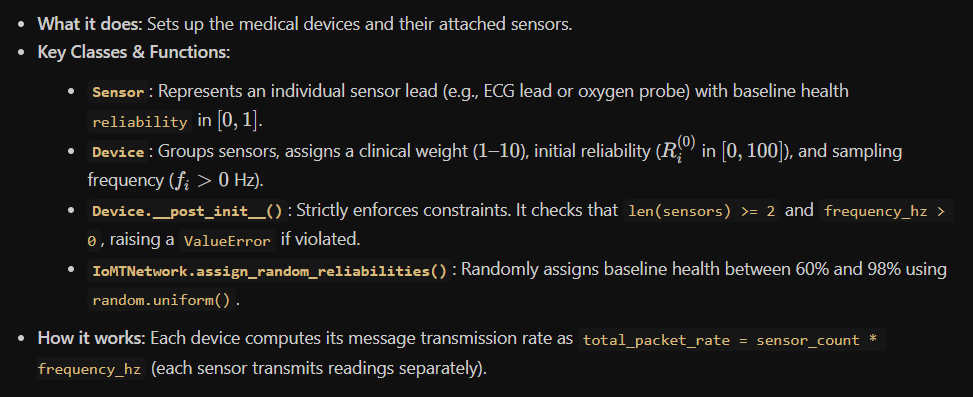

**Module 2: Communication Protocol & Threat Profiler**
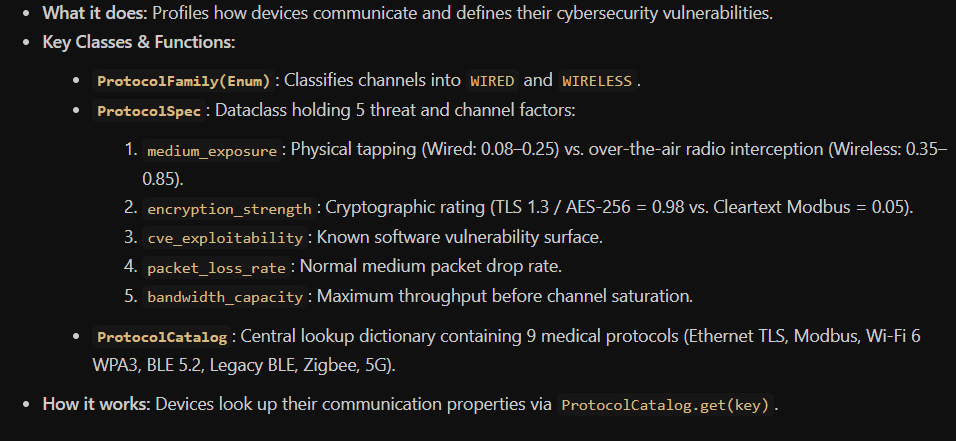

**Module 3: Sensor Subsystem & Channel Stress Evaluator**

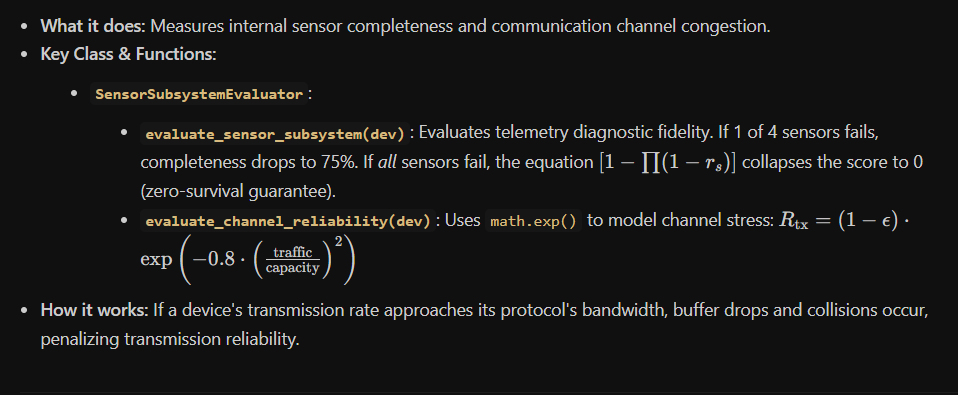

**Module 4: Inter-Device Relationship & Cascade Network Engine**

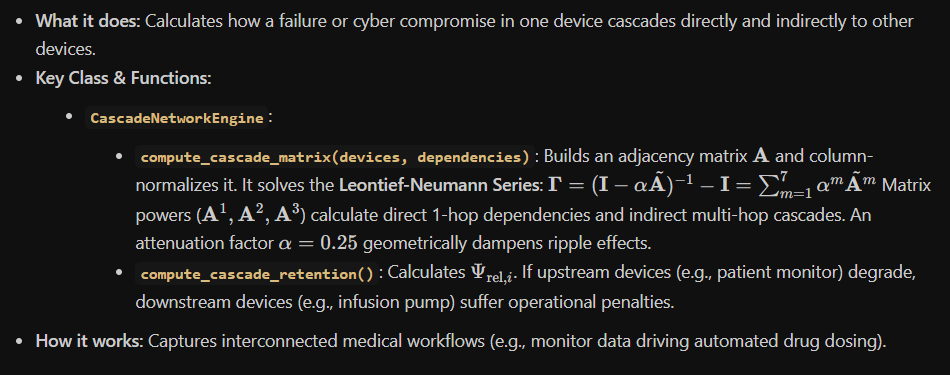

**Module 5: Security Exposure & Lateral Contagion Engine**

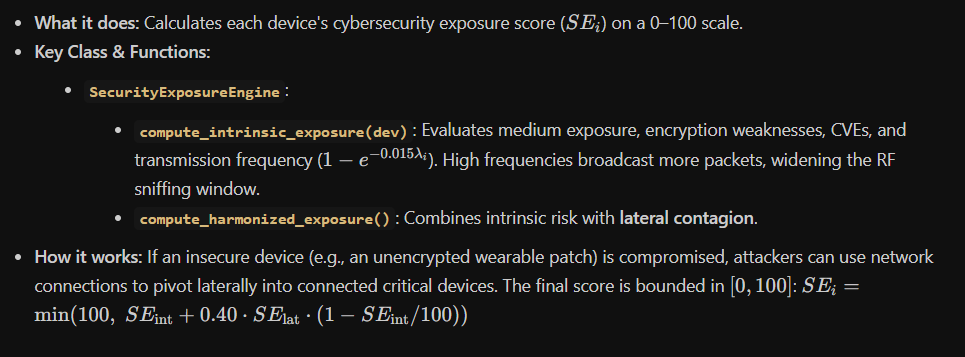

**Module 6: Composite Device Reliability Evaluator**
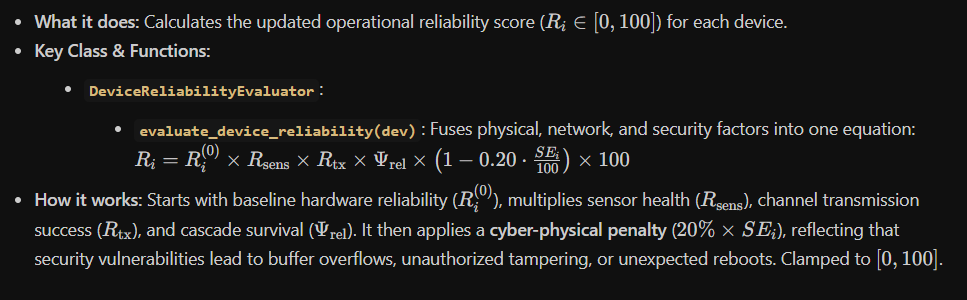

**Module 7: Derived Edge Gateway Reliability Engine**
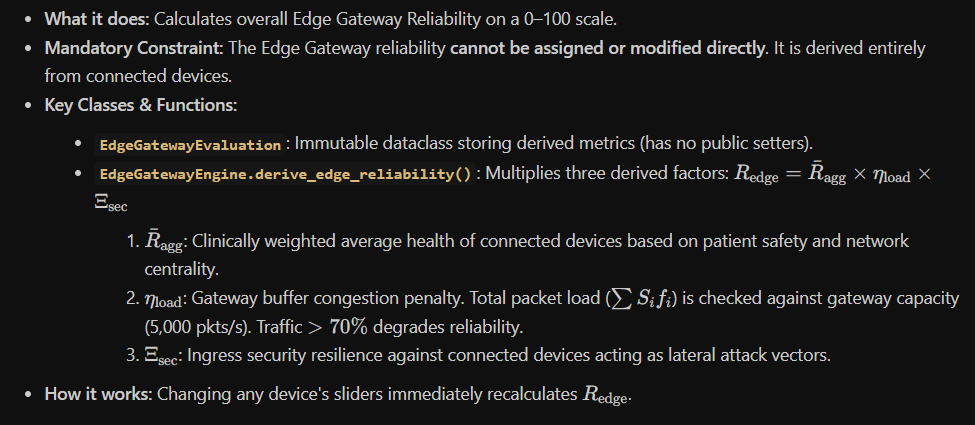

**Module 8: Systemic Criticality & Marginal Sensitivity Analyzer**
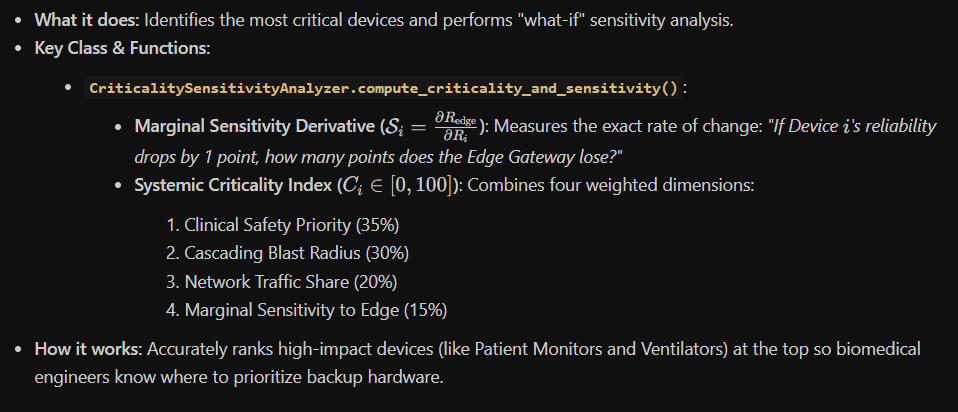

**Module 9: Scenario Simulation & Benchmarking Harness**

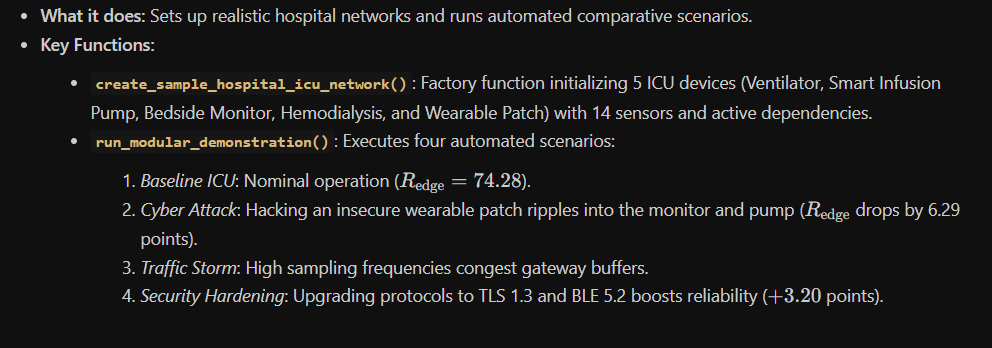

**Module 10: Export, Serialization & CLI Presentation Layer**

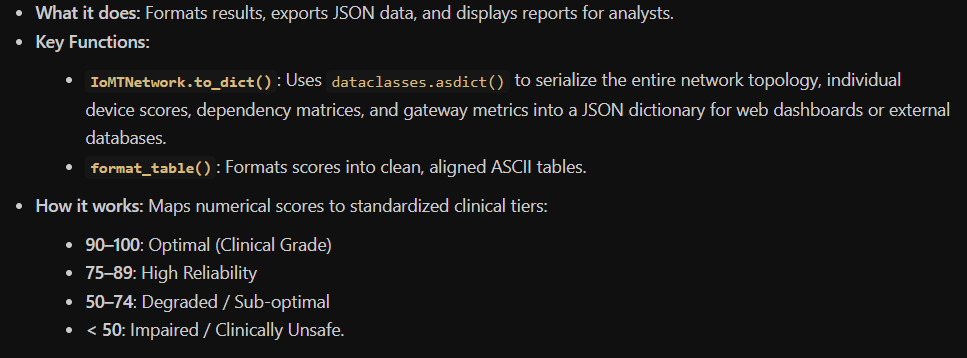